
Percent of each generation giving each violence_gp response:
               n  1 = Always acceptable  2 = Sometimes acceptable  \
generation                                                          
Silent        34                    0.0                       0.0   
Baby Boomer  298                    0.3                       1.7   
Gen X        256                    0.4                       4.7   
Millennial   268                    3.7                      13.1   
Gen Z        143                    7.7                      18.2   

             3 = Rarely acceptable  4 = Never acceptable  
generation                                                
Silent                         2.9                  97.1  
Baby Boomer                    3.7                  94.3  
Gen X                          6.6                  88.3  
Millennial                    13.8                  69.4  
Gen Z                         17.5                  56.6  


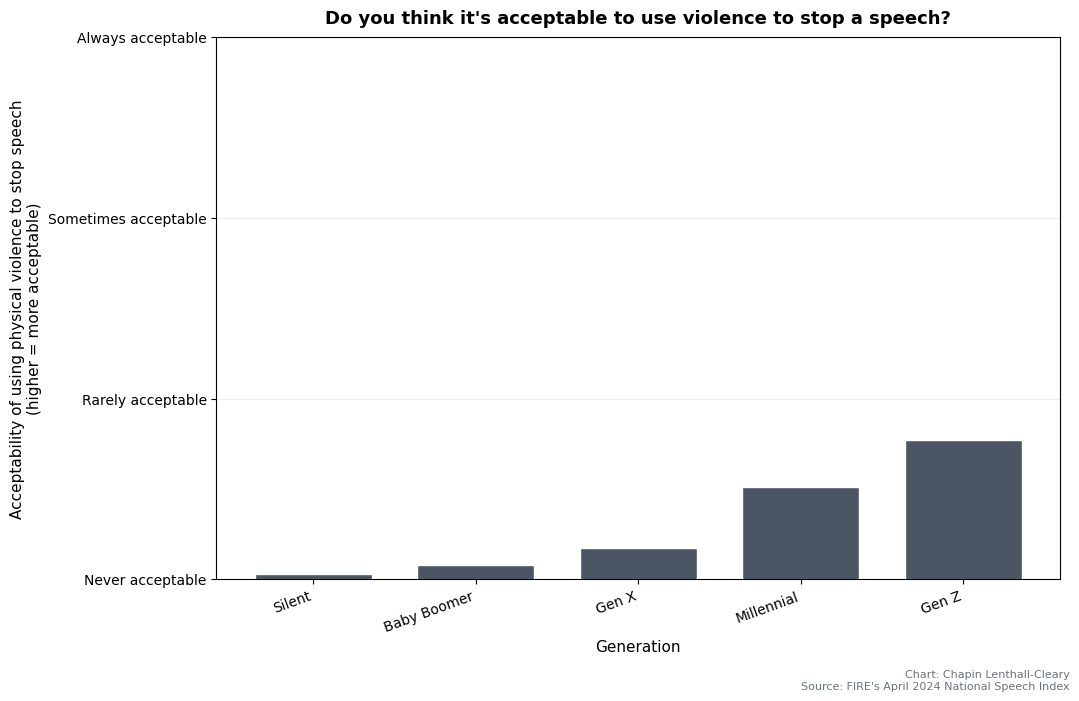

Saved: violence_gp_acceptability_bar_by_generation.png


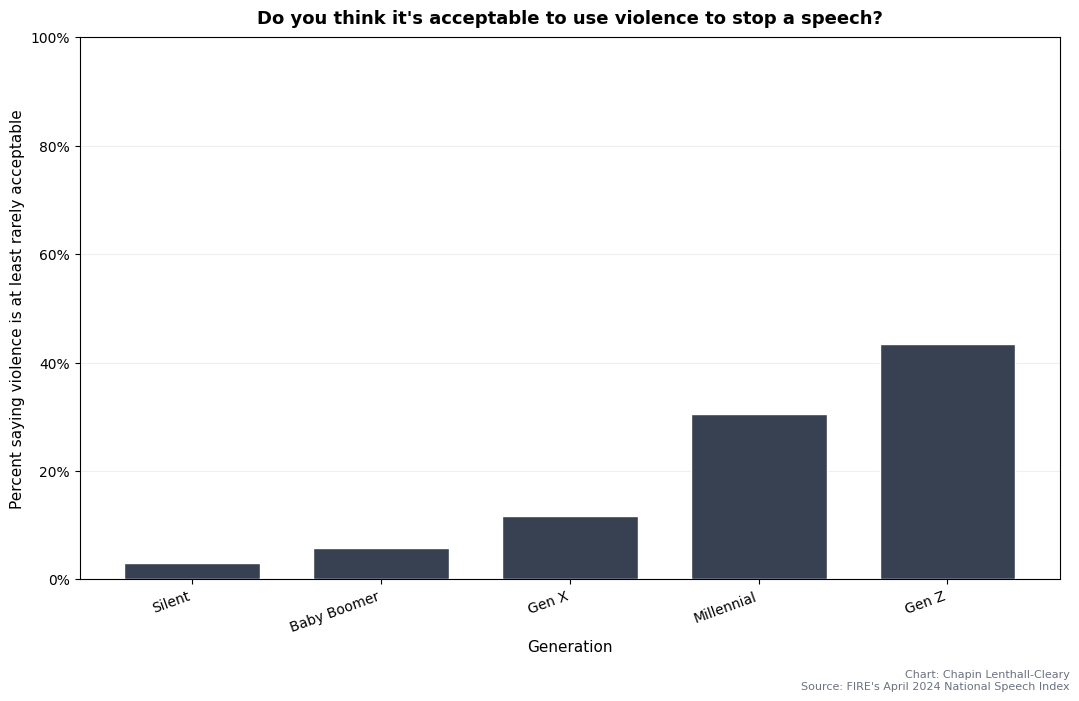

Saved: violence_gp_at_least_rarely_pct_by_generation.png


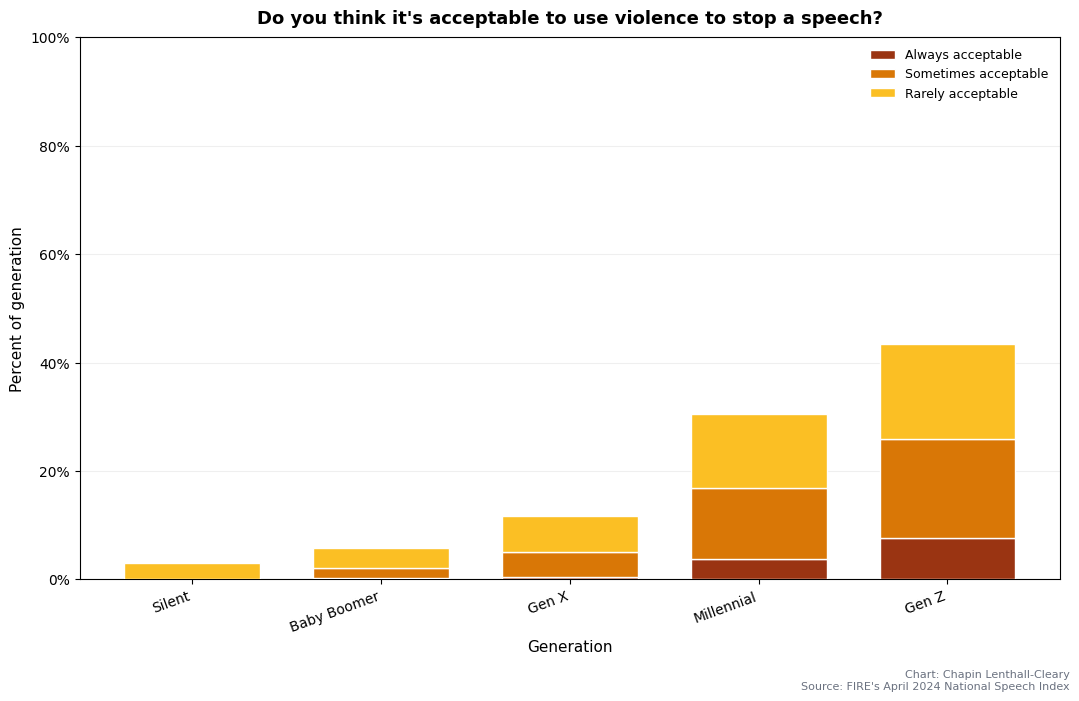

Saved: violence_gp_rarely_or_more_stacked_by_generation.png


In [1]:
#!/usr/bin/env python3
"""
Acceptability of violence against speakers (violence_gp) bar plot by generation.

- Source variable: violence_gp
- Recode for plotting: acceptability_score = 5 - violence_gp
  (so higher values = higher acceptability)
- Y-axis ticks use codebook response labels.
"""

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

MEGA_CSV_CANDIDATES = [
    Path("NSI_MEGA.csv"),
    Path("/Users/chapin.lenthall-cleary/Downloads/NSI_MEGA.csv"),
]

SURVEY_LABELS = {
    1: "January 2024",
    2: "April 2024",
    3: "July 2024",
    4: "October 2024",
    5: "January 2025",
    6: "April 2025",
    7: "July 2025",
    8: "October 2025",
    9: "January 2026",
}

GENERATION_ORDER = [
    "Greatest",
    "Silent",
    "Baby Boomer",
    "Gen X",
    "Millennial",
    "Gen Z",
]

# Axis is recoded so higher = more acceptable; labels point back to codebook anchors.
CODEBOOK_TICK_LABELS = {
    1: "Never acceptable",
    2: "Rarely acceptable",
    3: "Sometimes acceptable",
    4: "Always acceptable",
}

RAW_RESPONSE_LABELS = {
    1: "1 = Always acceptable",
    2: "2 = Sometimes acceptable",
    3: "3 = Rarely acceptable",
    4: "4 = Never acceptable",
}

CREDIT_TEXT = "Chart: Chapin Lenthall-Cleary\nSource: FIRE's National Speech Index"


def infer_month_year(df):
    if "survey" not in df.columns:
        return "Unknown month/year"
    s = pd.to_numeric(df["survey"], errors="coerce")
    rounds = sorted(s.dropna().astype(int).unique().tolist())
    if not rounds:
        return "Unknown month/year"
    labels = [SURVEY_LABELS.get(r, f"Survey {r}") for r in rounds]
    return labels[0] if len(labels) == 1 else "Multiple waves: " + ", ".join(labels)


def assign_generation(birthyr_series):
    b = pd.to_numeric(birthyr_series, errors="coerce")
    out = pd.Series(index=b.index, dtype="object")
    out.loc[b.between(1900, 1927)] = "Greatest"
    out.loc[b.between(1928, 1945)] = "Silent"
    out.loc[b.between(1946, 1964)] = "Baby Boomer"
    out.loc[b.between(1965, 1980)] = "Gen X"
    out.loc[b.between(1981, 1996)] = "Millennial"
    out.loc[b.between(1997, 2012)] = "Gen Z"
    return pd.Categorical(out, categories=GENERATION_ORDER, ordered=True)


def main():
    mega_path = next((p for p in MEGA_CSV_CANDIDATES if p.exists()), None)
    if mega_path is None:
        raise SystemExit("Could not find NSI_MEGA.csv.")

    df = pd.read_csv(mega_path, low_memory=False)

    needed = {"birthyr", "violence_gp"}
    if not needed.issubset(df.columns):
        raise SystemExit(f"Missing required columns: {sorted(needed - set(df.columns))}")

    use = df.copy()
    for c in ["birthyr", "violence_gp", "survey"]:
        if c in use.columns:
            use[c] = pd.to_numeric(use[c], errors="coerce")

    use = use[
        use["birthyr"].between(1900, 2010)
        & use["violence_gp"].between(1, 4)
    ].copy()
    if use.empty:
        raise SystemExit("No valid rows for violence_gp in [1,4] with valid birth year.")

    # Higher score = more acceptable use of violence against a speaker.
    use["acceptability_score"] = 5.0 - use["violence_gp"]
    use["generation"] = assign_generation(use["birthyr"])
    use = use[use["generation"].notna()].copy()
    if use.empty:
        raise SystemExit("No rows remain after generation assignment.")

    summary = (
        use.groupby("generation", observed=True, as_index=False)
        .agg(avg_acceptability=("acceptability_score", "mean"), n=("acceptability_score", "size"))
    )

    # Keep only generations that actually have data.
    resp_n_full = use.groupby("generation", observed=True).size().reindex(GENERATION_ORDER, fill_value=0)
    active_generations = [g for g in GENERATION_ORDER if int(resp_n_full.loc[g]) > 0]
    if not active_generations:
        raise SystemExit("No generation groups with data for violence_gp.")

    summary = summary[summary["generation"].isin(active_generations)].copy()
    summary["generation"] = pd.Categorical(summary["generation"], categories=active_generations, ordered=True)
    summary = summary.sort_values("generation")

    # Table: percent of each generation giving each original codebook response.
    resp_pct = (
        use.groupby("generation", observed=True)["violence_gp"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(index=active_generations, columns=[1, 2, 3, 4], fill_value=0)
        * 100.0
    )
    resp_pct.columns = [RAW_RESPONSE_LABELS[c] for c in resp_pct.columns]
    resp_n = resp_n_full.reindex(active_generations)
    resp_table = resp_pct.round(1)
    resp_table.insert(0, "n", resp_n.astype(int))

    print("\nPercent of each generation giving each violence_gp response:")
    print(resp_table)

    month_year = infer_month_year(use)

    x = np.arange(len(summary))
    xlabels = summary["generation"].astype(str).tolist()
    y = summary["avg_acceptability"].to_numpy()

    fig, ax = plt.subplots(figsize=(10.8, 7.0))

    bars = ax.bar(
        x,
        y,
        color="#4b5563",
        edgecolor="white",
        linewidth=1.0,
        width=0.72,
        zorder=3,
    )

    ax.set_xticks(x)
    ax.set_xticklabels(xlabels, rotation=20, ha="right", fontsize=10)
    ax.set_xlabel("Generation", fontsize=11)

    ax.set_ylim(1, 4)
    ax.set_yticks([1, 2, 3, 4])
    ax.set_yticklabels([CODEBOOK_TICK_LABELS[v] for v in [1, 2, 3, 4]], fontsize=10)
    ax.set_ylabel(
        "Acceptability of using physical violence to stop speech\n"
        "(higher = more acceptable)",
        fontsize=11,
    )

    ax.set_title(
        "Do you think it's acceptable to use violence to stop a speech?",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )
    ax.grid(axis="y", alpha=0.2, zorder=1)

    fig.tight_layout(rect=[0, 0.035, 1, 1])
    fig.text(
        0.995,
        0.005,
        f"Chart: Chapin Lenthall-Cleary\nSource: FIRE's {month_year} National Speech Index",
        ha="right",
        va="bottom",
        fontsize=8,
        color="#6b7280",
    )
    out = "violence_gp_acceptability_bar_by_generation.png"
    fig.savefig(out, dpi=150)
    plt.show()
    print(f"Saved: {out}")

    # Second chart: percent saying violence is at least rarely acceptable.
    # violence_gp coding: 1=Always, 2=Sometimes, 3=Rarely, 4=Never acceptable.
    use["at_least_rarely"] = use["violence_gp"].isin([1, 2, 3]).astype(float)
    pct_summary = (
        use.groupby("generation", observed=True, as_index=False)
        .agg(pct_at_least_rarely=("at_least_rarely", "mean"), n=("at_least_rarely", "size"))
    )
    pct_summary["generation"] = pd.Categorical(
        pct_summary["generation"], categories=active_generations, ordered=True
    )
    pct_summary = pct_summary.sort_values("generation")

    x2 = np.arange(len(pct_summary))
    x2labels = pct_summary["generation"].astype(str).tolist()
    y2 = (pct_summary["pct_at_least_rarely"] * 100.0).to_numpy()

    fig2, ax2 = plt.subplots(figsize=(10.8, 7.0))
    bars2 = ax2.bar(
        x2,
        y2,
        color="#374151",
        edgecolor="white",
        linewidth=1.0,
        width=0.72,
        zorder=3,
    )

    ax2.set_xticks(x2)
    ax2.set_xticklabels(x2labels, rotation=20, ha="right", fontsize=10)
    ax2.set_xlabel("Generation", fontsize=11)
    ax2.set_ylim(0, 100)
    ax2.set_yticks([0, 20, 40, 60, 80, 100])
    ax2.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"], fontsize=10)
    ax2.set_ylabel("Percent saying violence is at least rarely acceptable", fontsize=11)
    ax2.set_title(
        "Do you think it's acceptable to use violence to stop a speech?",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )
    ax2.grid(axis="y", alpha=0.2, zorder=1)

    fig2.tight_layout(rect=[0, 0.035, 1, 1])
    fig2.text(
        0.995,
        0.005,
        f"Chart: Chapin Lenthall-Cleary\nSource: FIRE's {month_year} National Speech Index",
        ha="right",
        va="bottom",
        fontsize=8,
        color="#6b7280",
    )
    out2 = "violence_gp_at_least_rarely_pct_by_generation.png"
    fig2.savefig(out2, dpi=150)
    plt.show()
    print(f"Saved: {out2}")

    # Third chart: stacked composition of "at least rarely acceptable" responses.
    # Stack order bottom->top: Always (1), Sometimes (2), Rarely (3).
    stack_pct = (
        use.groupby("generation", observed=True)["violence_gp"]
        .value_counts(normalize=True)
        .unstack(fill_value=0)
        .reindex(index=active_generations, columns=[1, 2, 3], fill_value=0)
        * 100.0
    )

    x3 = np.arange(len(stack_pct))
    x3labels = stack_pct.index.astype(str).tolist()
    always = stack_pct[1].to_numpy()
    sometimes = stack_pct[2].to_numpy()
    rarely = stack_pct[3].to_numpy()

    fig3, ax3 = plt.subplots(figsize=(10.8, 7.0))
    ax3.bar(
        x3,
        always,
        width=0.72,
        color="#9a3412",
        edgecolor="white",
        linewidth=1.0,
        label="Always acceptable",
        zorder=3,
    )
    ax3.bar(
        x3,
        sometimes,
        width=0.72,
        bottom=always,
        color="#d97706",
        edgecolor="white",
        linewidth=1.0,
        label="Sometimes acceptable",
        zorder=3,
    )
    ax3.bar(
        x3,
        rarely,
        width=0.72,
        bottom=always + sometimes,
        color="#fbbf24",
        edgecolor="white",
        linewidth=1.0,
        label="Rarely acceptable",
        zorder=3,
    )

    ax3.set_xticks(x3)
    ax3.set_xticklabels(x3labels, rotation=20, ha="right", fontsize=10)
    ax3.set_xlabel("Generation", fontsize=11)
    ax3.set_ylim(0, 100)
    ax3.set_yticks([0, 20, 40, 60, 80, 100])
    ax3.set_yticklabels(["0%", "20%", "40%", "60%", "80%", "100%"], fontsize=10)
    ax3.set_ylabel("Percent of generation", fontsize=11)
    ax3.set_title(
        "Do you think it's acceptable to use violence to stop a speech?",
        fontsize=13,
        fontweight="bold",
        pad=10,
    )
    ax3.legend(loc="upper right", frameon=False, fontsize=9)
    ax3.grid(axis="y", alpha=0.2, zorder=1)

    fig3.tight_layout(rect=[0, 0.035, 1, 1])
    fig3.text(
        0.995,
        0.005,
        f"Chart: Chapin Lenthall-Cleary\nSource: FIRE's {month_year} National Speech Index",
        ha="right",
        va="bottom",
        fontsize=8,
        color="#6b7280",
    )
    out3 = "violence_gp_rarely_or_more_stacked_by_generation.png"
    fig3.savefig(out3, dpi=150)
    plt.show()
    print(f"Saved: {out3}")


if __name__ == "__main__":
    main()
